# lab-4 : Single Layer Perceptron and Multi-Layer Perceptron

## Task 1 — Single Layer Perceptron (from scratch)

Final Weights: [0.48224343 0.47655682]
Final Bias: 0.0
Training Accuracy: 100.0 %


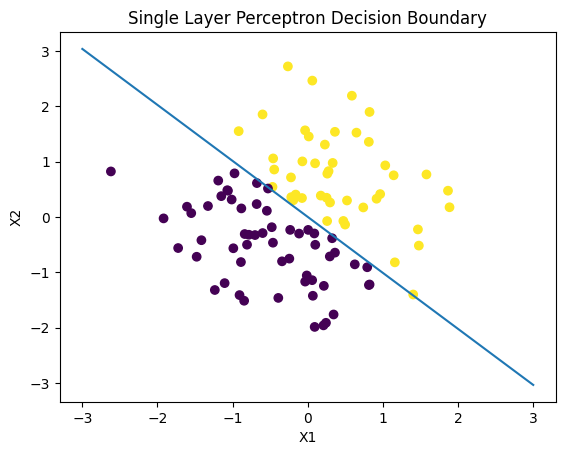

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Step 1: Define Step Function
# ------------------------------
def step_function(x):
    return np.where(x >= 0, 1, 0)

# ------------------------------
# Step 2: Generate Synthetic Data
# ------------------------------
np.random.seed(42)

# 100 random 2D points
X = np.random.randn(100, 2)

# Linear rule: x1 + x2 > 0
y = step_function(X[:, 0] + X[:, 1])

# ------------------------------
# Step 3: Initialize Parameters
# ------------------------------
weights = np.random.randn(2)
bias = 0
learning_rate = 0.1
epochs = 100

# ------------------------------
# Step 4: Train Perceptron
# ------------------------------
for epoch in range(epochs):
    for i in range(len(X)):

        # Linear combination
        linear_output = np.dot(X[i], weights) + bias

        # Prediction
        prediction = step_function(linear_output)

        # Error
        error = y[i] - prediction

        # Update weights and bias
        weights += learning_rate * error * X[i]
        bias += learning_rate * error

# ------------------------------
# Step 5: Evaluate Model
# ------------------------------
predictions = step_function(np.dot(X, weights) + bias)
accuracy = np.mean(predictions == y)

print("Final Weights:", weights)
print("Final Bias:", bias)
print("Training Accuracy:", accuracy * 100, "%")

# ------------------------------
# Step 6: Plot Decision Boundary
# ------------------------------
x_values = np.linspace(-3, 3, 100)
y_values = -(weights[0] * x_values + bias) / weights[1]

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot(x_values, y_values)
plt.title("Single Layer Perceptron Decision Boundary")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

## Task 2 — Multi-Layer Perceptron (MLP)

Final Predictions:
 [[0]
 [1]
 [1]
 [0]]
Actual Labels:
 [[0]
 [1]
 [1]
 [0]]
Training Accuracy: 100.0 %


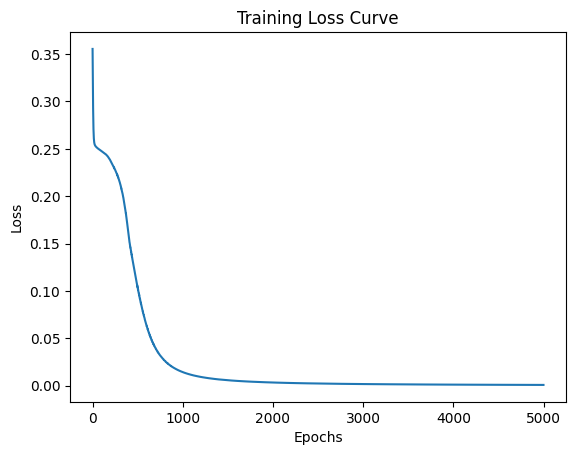

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# a. Generate Non-Linear Data (XOR)
# ------------------------------
np.random.seed(42)

X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],[1],[1],[0]])

# ------------------------------
# b. Define Activation Functions
# ------------------------------
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# ------------------------------
# c. Initialize Weights & Biases
# ------------------------------
input_neurons = 2
hidden_neurons = 4
output_neurons = 1

W1 = np.random.randn(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.randn(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))

learning_rate = 0.1
epochs = 5000
losses = []

# ------------------------------
# d. Train with Backpropagation
# ------------------------------
for epoch in range(epochs):

    # Forward Pass
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Loss (Mean Squared Error)
    loss = np.mean((y - A2) ** 2)
    losses.append(loss)

    # Backpropagation
    dA2 = A2 - y
    dZ2 = dA2 * sigmoid_derivative(A2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update Weights
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# ------------------------------
# e. Evaluate Model
# ------------------------------
Z1 = np.dot(X, W1) + b1
A1 = relu(Z1)
Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

predictions = np.where(A2 >= 0.5, 1, 0)
accuracy = np.mean(predictions == y)

print("Final Predictions:\n", predictions)
print("Actual Labels:\n", y)
print("Training Accuracy:", accuracy * 100, "%")

# ------------------------------
# Plot Loss Curve
# ------------------------------
plt.figure()
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## Task 3 — Perform following tasks:

1.	Compare single layer vs MLP on linearly separable vs non-linear data (e.g., XOR).
2.	Explore how hidden layer size impacts learning.
3.	Plot loss over training epochs.


---- Perceptron Results ----
Linear Data Accuracy: 100.0 %
XOR Data Accuracy: 50.0 %

---- MLP Results (Different Hidden Sizes on XOR) ----
Hidden Neurons = 2 → Accuracy = 75.0%
Hidden Neurons = 4 → Accuracy = 100.0%
Hidden Neurons = 8 → Accuracy = 100.0%


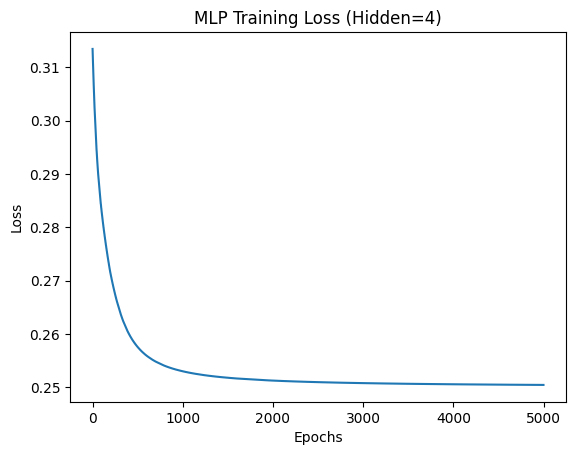

In [4]:
# =========================================================
# LAB 4 - Task 3: Comparison & Analysis
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ---------------------------------------------------------
# 1. Generate Datasets
# ---------------------------------------------------------

# Linearly Separable Data
X_linear = np.random.randn(100, 2)
y_linear = np.where(X_linear[:, 0] + X_linear[:, 1] > 0, 1, 0)

# XOR Data (Non-linear)
X_xor = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_xor = np.array([[0],[1],[1],[0]])

# ---------------------------------------------------------
# 2. Single Layer Perceptron
# ---------------------------------------------------------

def step(x):
    return np.where(x >= 0, 1, 0)

def train_perceptron(X, y, epochs=100, lr=0.1):
    weights = np.random.randn(2)
    bias = 0

    for epoch in range(epochs):
        for i in range(len(X)):
            linear_output = np.dot(X[i], weights) + bias
            prediction = step(linear_output)
            error = y[i] - prediction
            weights += lr * error * X[i]
            bias += lr * error

    predictions = step(np.dot(X, weights) + bias)
    accuracy = np.mean(predictions == y)
    return accuracy

# Train Perceptron
acc_linear_per = train_perceptron(X_linear, y_linear)
acc_xor_per = train_perceptron(X_xor, y_xor.flatten())

# ---------------------------------------------------------
# 3. Multi-Layer Perceptron (MLP)
# ---------------------------------------------------------

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def train_mlp(X, y, hidden_neurons=4, epochs=5000, lr=0.1):

    input_neurons = X.shape[1]
    output_neurons = 1

    W1 = np.random.randn(input_neurons, hidden_neurons)
    b1 = np.zeros((1, hidden_neurons))

    W2 = np.random.randn(hidden_neurons, output_neurons)
    b2 = np.zeros((1, output_neurons))

    losses = []

    for epoch in range(epochs):

        # Forward
        Z1 = np.dot(X, W1) + b1
        A1 = relu(Z1)
        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)

        loss = np.mean((y.reshape(-1,1) - A2) ** 2)
        losses.append(loss)

        # Backprop
        dA2 = A2 - y.reshape(-1,1)
        dZ2 = dA2 * sigmoid_derivative(A2)
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = np.dot(X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    predictions = np.where(A2 >= 0.5, 1, 0)
    accuracy = np.mean(predictions == y.reshape(-1,1))

    return accuracy, losses

# ---------------------------------------------------------
# 4. Train MLP with Different Hidden Sizes
# ---------------------------------------------------------

hidden_sizes = [2, 4, 8]

print("---- Perceptron Results ----")
print("Linear Data Accuracy:", acc_linear_per * 100, "%")
print("XOR Data Accuracy:", acc_xor_per * 100, "%")

print("\n---- MLP Results (Different Hidden Sizes on XOR) ----")

for size in hidden_sizes:
    acc, losses = train_mlp(X_xor, y_xor, hidden_neurons=size)
    print(f"Hidden Neurons = {size} → Accuracy = {acc * 100}%")

# ---------------------------------------------------------
# 5. Plot Loss for Best Hidden Size (4 neurons)
# ---------------------------------------------------------

_, losses = train_mlp(X_xor, y_xor, hidden_neurons=4)

plt.figure()
plt.plot(losses)
plt.title("MLP Training Loss (Hidden=4)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()